In [ ]:
import pandas as pd

# load your data (example)
df_obs = pd.read_csv("data/data_1519.csv", header=None) #observational
df_intA = pd.read_csv("data/data_1529A0.csv", header=None) #intervened A = 0
df_intB = pd.read_csv("data/data_1560B0.csv", header=None) #intervened B = 0
df_intC = pd.read_csv("data/data_1530C0.csv", header=None) #intervened C = 0
df_intD = pd.read_csv("data/data_1532D0.csv", header=None) #intervened D = 0

df_obs = df_obs.drop([0], axis=1).drop([0], axis=0)  # Drop the first column and row
df_obs.columns = ["A", "B", "C", "D"]  # Assuming the first column is an index or identifier

df_intA = df_intA.drop([0], axis=1).drop([0], axis=0)  # Drop the first column and row
df_intB = df_intB.drop([0], axis=1).drop([0], axis=0)  # Drop the first column and row
df_intC = df_intC.drop([0], axis=1).drop([0], axis=0)  # Drop the first column and row
df_intD = df_intD.drop([0], axis=1).drop([0], axis=0)  # Drop the first column and row
df_intA.columns = ["A", "B", "C", "D"]  # Assuming the first column is an index or identifier
df_intB.columns = ["A", "B", "C", "D"]  # Assuming the first column is an index or identifier
df_intC.columns = ["A", "B", "C", "D"]  # Assuming the first column is an index or identifier
df_intD.columns = ["A", "B", "C", "D"]  # Assuming the first column is an index or identifier

# compute correlation matrix
corr_obs = df_obs.corr()
corr_intA = df_intA.corr()
corr_intB = df_intB.corr()
corr_intC = df_intC.corr()
corr_intD = df_intD.corr()

print(corr_obs)
print(corr_intA)
print(corr_intB)
print(corr_intC)
print(corr_intD)

          A         B         C         D
A  1.000000  0.033324  0.647309  0.882476
B  0.033324  1.000000  0.034591 -0.260940
C  0.647309  0.034591  1.000000  0.570813
D  0.882476 -0.260940  0.570813  1.000000
    A         B         C         D
A NaN       NaN       NaN       NaN
B NaN  1.000000  0.031097 -0.655724
C NaN  0.031097  1.000000 -0.006651
D NaN -0.655724 -0.006651  1.000000
          A   B         C         D
A  1.000000 NaN  0.551300  0.933975
B       NaN NaN       NaN       NaN
C  0.551300 NaN  1.000000  0.530886
D  0.933975 NaN  0.530886  1.000000
          A         B   C         D
A  1.000000  0.014290 NaN  0.861338
B  0.014290  1.000000 NaN -0.300593
C       NaN       NaN NaN       NaN
D  0.861338 -0.300593 NaN  1.000000
          A         B         C   D
A  1.000000 -0.012921  0.597952 NaN
B -0.012921  1.000000  0.021801 NaN
C  0.597952  0.021801  1.000000 NaN
D       NaN       NaN       NaN NaN


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add labels to identify datasets
df_obs["type"] = "obs"
df_intA["type"] = "do(A=0)"
df_intB["type"] = "do(B=0)"
df_intC["type"] = "do(C=0)"
df_intD["type"] = "do(D=0)"

# Combine all
df_all = pd.concat([df_obs, df_intA, df_intB, df_intC, df_intD])

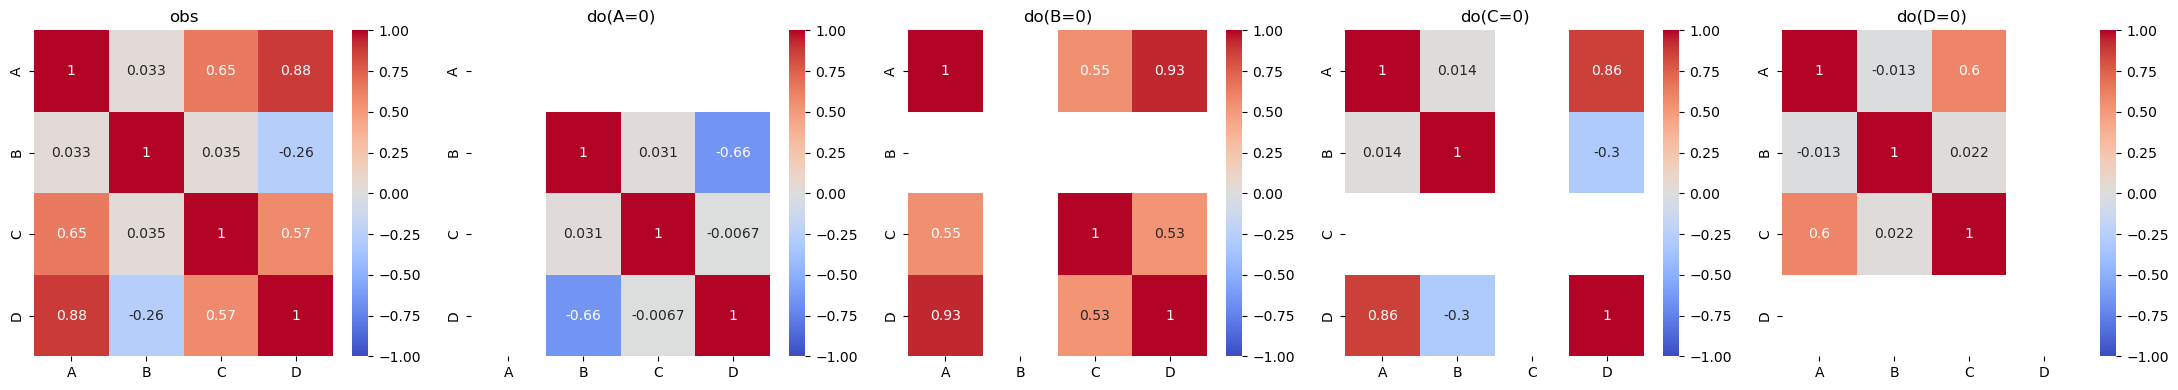

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

datasets = {
    "obs": df_obs,
    "do(A=0)": df_intA,
    "do(B=0)": df_intB,
    "do(C=0)": df_intC,
    "do(D=0)": df_intD
}

variables = ["A", "B", "C", "D"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    corr = df[variables].astype(float).corr()

    sns.heatmap(
        corr,
        annot=True,
        vmin=-1,
        vmax=1,
        cmap="coolwarm",
        ax=ax
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

ValueError: could not convert string to float: 'obs'

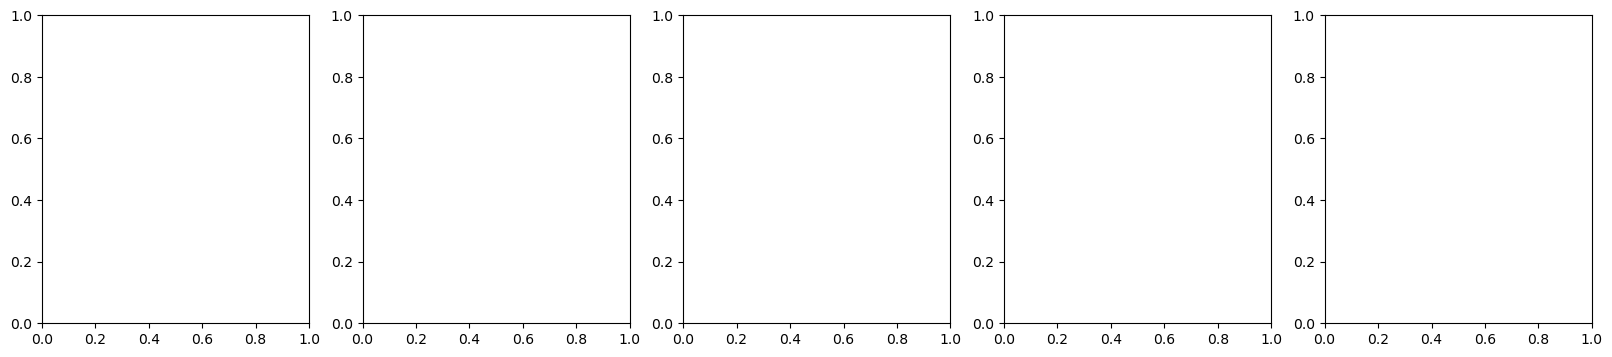

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    sns.heatmap(df.corr(), annot=True, cmap="coolwarm", ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

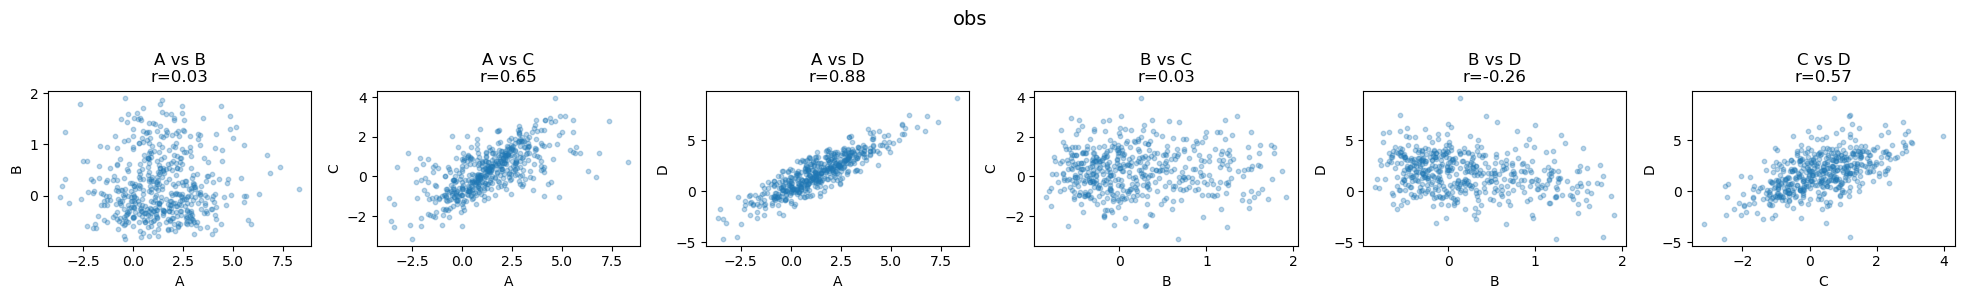

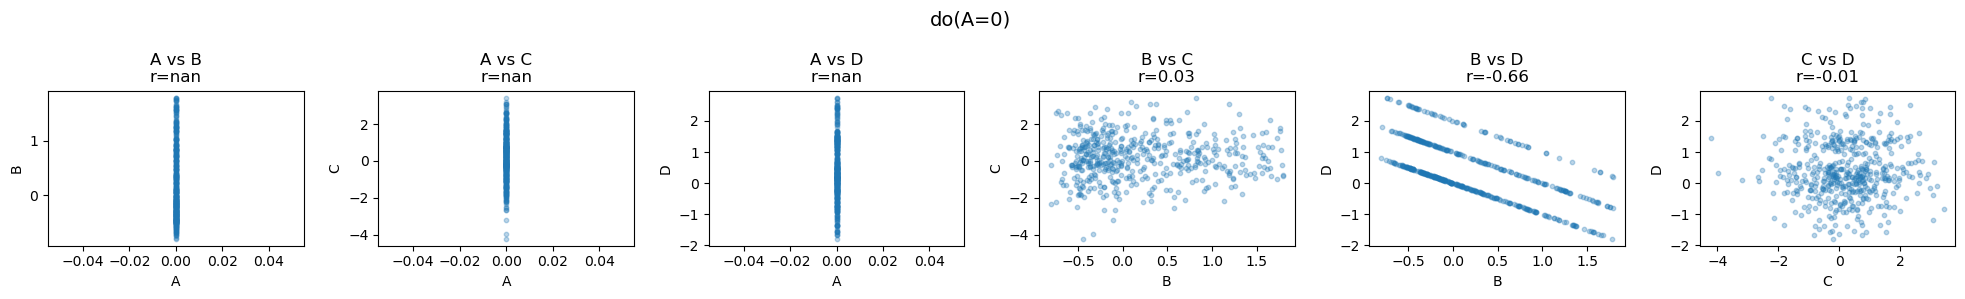

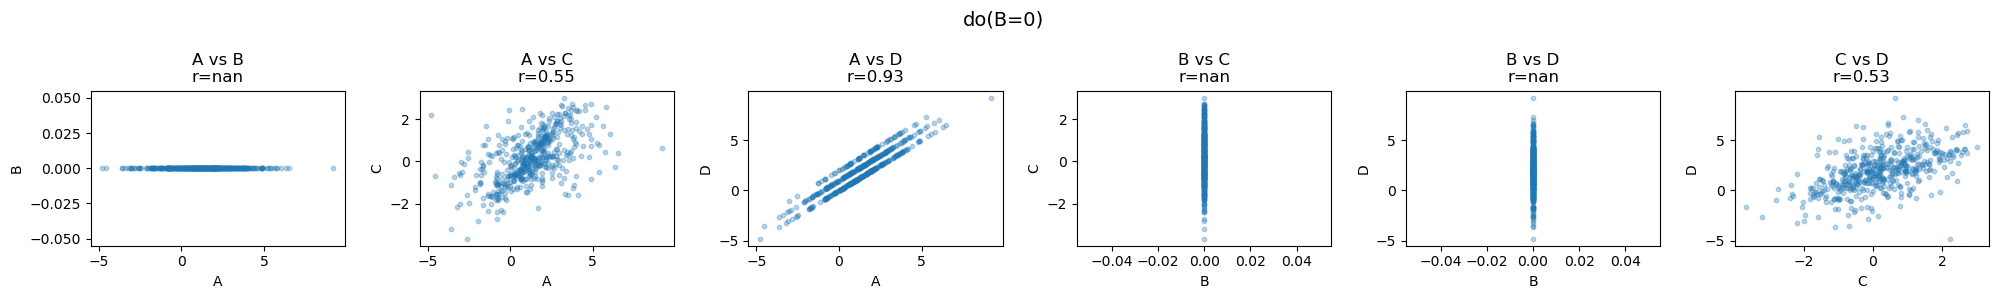

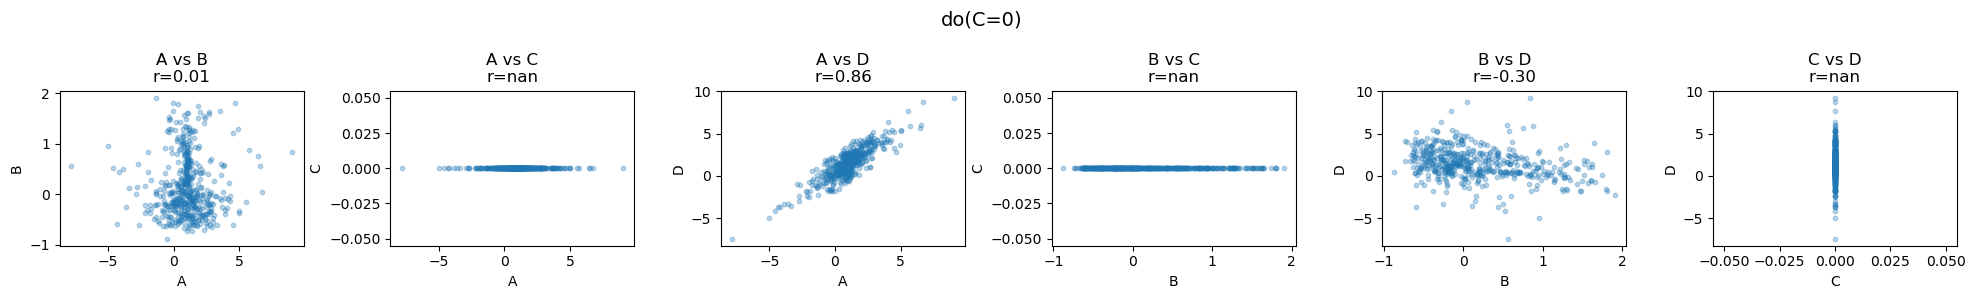

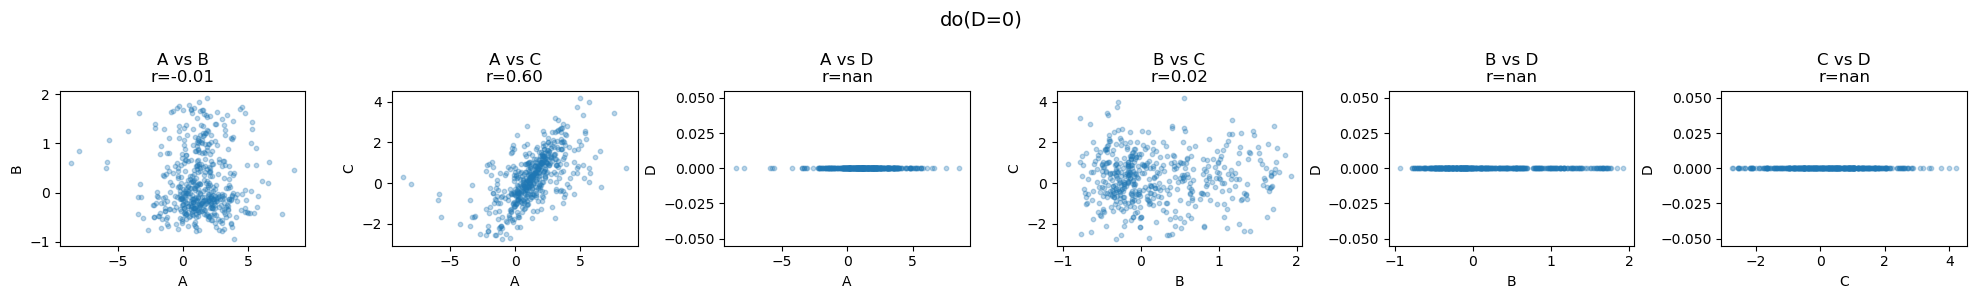

In [13]:
import matplotlib.pyplot as plt
import itertools
import pandas as pd

datasets = {
    "obs": df_obs,
    "do(A=0)": df_intA,
    "do(B=0)": df_intB,
    "do(C=0)": df_intC,
    "do(D=0)": df_intD
}

variables = ["A", "B", "C", "D"]
pairs = list(itertools.combinations(variables, 2))

for name, df in datasets.items():

    # Make sure A, B, C, D are numeric
    df_plot = df[variables].apply(pd.to_numeric, errors="coerce").dropna()

    fig, axes = plt.subplots(1, 6, figsize=(20, 3))
    fig.suptitle(name, fontsize=14)

    for ax, (x, y) in zip(axes, pairs):
        ax.scatter(df_plot[x], df_plot[y], alpha=0.3, s=10)

        if df_plot[x].std() > 0 and df_plot[y].std() > 0:
            r = df_plot[x].corr(df_plot[y])
            ax.set_title(f"{x} vs {y}\nr={r:.2f}")
        else:
            ax.set_title(f"{x} vs {y}\nr=nan")

        ax.set_xlabel(x)
        ax.set_ylabel(y)

    plt.tight_layout()
    plt.show()